### Data Visualization for `merged_data.csv`

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import zipfile 
import os 

In [3]:
os.getcwd()
path = '/Users/iriskwon/Documents/Spr26/MLMA Final Project/MLMAMidtermProject' # set directory to your GitHub repo! 

In [4]:
with zipfile.ZipFile('merged_data.csv.zip') as z:
    with z.open('merged_data.csv') as f:
        df = pd.read_csv(f)

/var/folders/jc/r13c712s6dj2g5bnkv832wk40000gn/T/ipykernel_327/1736007017.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


In [5]:
df.head()

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


In [6]:
len(df['id'].unique())
unique_nurses_id = df['id'].unique()
print(unique_nurses_id)

# Convert all IDs to strings to standardize them
df['id'] = df['id'].astype(str)

# Check the unique nurse IDs after standardization
unique_nurses_id = df['id'].unique()
print(f"Number of unique nurse IDs: {len(unique_nurses_id)}")
print(unique_nurses_id)

[15 '15' '5C' '6B' '6D' '7A' '7E' '83' 83 '8B' '94' 94 'BG' 'CE' 'DF' 'E4'
 'EG' 'F5']
Number of unique nurse IDs: 15
['15' '5C' '6B' '6D' '7A' '7E' '83' '8B' '94' 'BG' 'CE' 'DF' 'E4' 'EG'
 'F5']


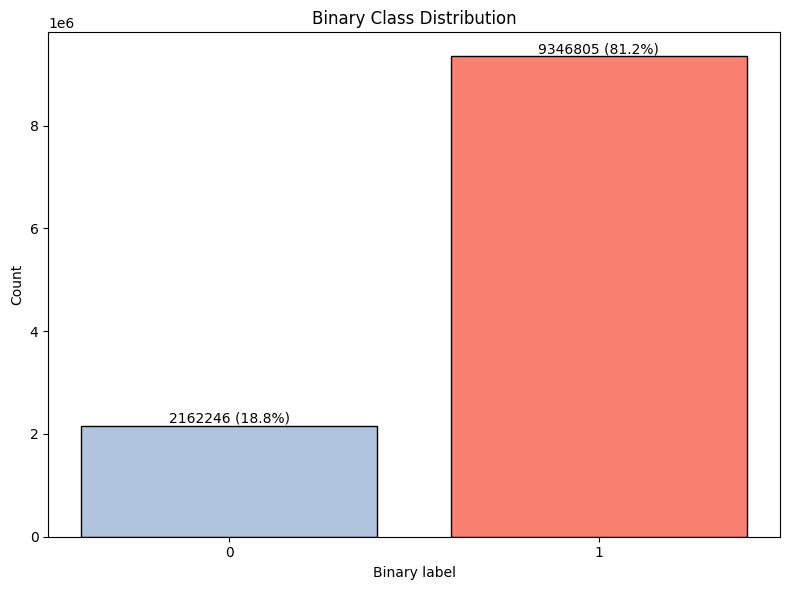

Binary class counts:
label
0    2162246
1    9346805
Name: count, dtype: int64

Binary class percentages:
label
0    18.79
1    81.21
Name: proportion, dtype: float64


In [14]:
# Binarize the label while keeping the original multiclass label
# 0 stays 0, and 1 and 2 are merged into 1
df['binarized_label'] = df['label'].apply(lambda x: 0 if x == 0 else 1)

# Copy for binary-class experiments if needed
binary_df = df.copy()
binary_df['label'] = binary_df['binarized_label']

# Visualize the binary class distribution to inspect imbalance
binary_counts = binary_df['label'].value_counts().sort_index()
binary_percent = binary_df['label'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 6))
bars = plt.bar(
    ['0', '1'],
    binary_counts.values,
    color=['lightsteelblue', 'salmon'],
    edgecolor='black'
)

for bar, count, pct in zip(bars, binary_counts.values, binary_percent.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count} ({pct:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.title('Binary Class Distribution')
plt.xlabel('Binary label')
plt.ylabel('Count')
plt.xticks([0, 1], ['0', '1'])
plt.tight_layout()
plt.show()

print('Binary class counts:')
print(binary_counts)
print('\nBinary class percentages:')
print(binary_percent.round(2))

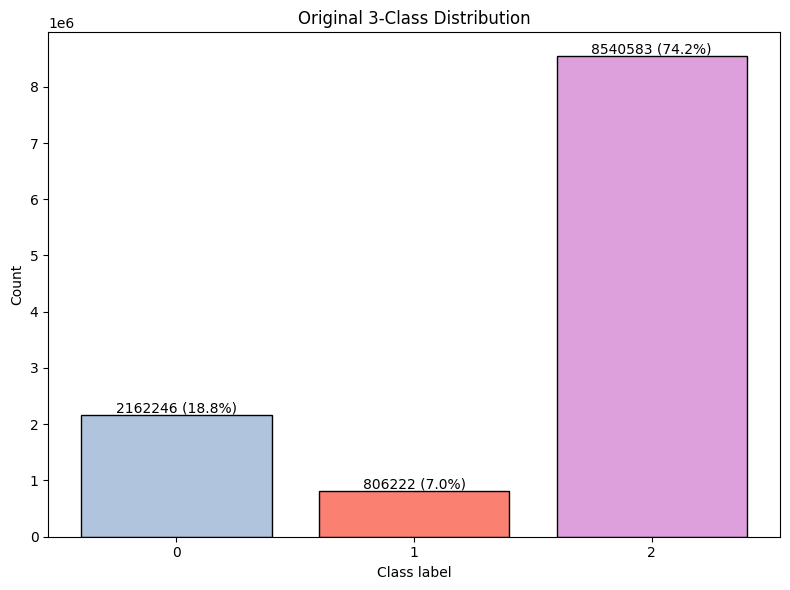

3-class counts:
label
0.0    2162246
1.0     806222
2.0    8540583
Name: count, dtype: int64

3-class percentages:
label
0.0    18.79
1.0     7.01
2.0    74.21
Name: proportion, dtype: float64


In [13]:
# Visualize the original 3-class distribution to inspect imbalance
class_counts = df['label'].value_counts().sort_index()
class_percent = df['label'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 6))
bars = plt.bar(
    ['0', '1', '2'],
    class_counts.values,
    color=['lightsteelblue', 'salmon', 'plum'],
    edgecolor='black'
)

for bar, count, pct in zip(bars, class_counts.values, class_percent.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count} ({pct:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.title('Original 3-Class Distribution')
plt.xlabel('Class label')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['0', '1', '2'])
plt.tight_layout()
plt.show()

print('3-class counts:')
print(class_counts)
print('\n3-class percentages:')
print(class_percent.round(2))

In [15]:
binary_df.head()

,X,Y,Z,EDA,HR,TEMP,id,datetime,label,label_binary,binarized_label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,1,1,1
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,1,1,1
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,1,1,1
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,1,1,1
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,1,1,1
